# Imports

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
# Definir ruta donde estan los archivos
path = r'../data/raw/'

In [3]:
# Listar archivos Parquet que comienzan con 'data'
all_files = glob.glob(os.path.join(path, 'data*.parquet'))

In [4]:
# Leer cada archivo Parquet y almacenarlo en una lista de DataFrames
df_list = []
for filename in all_files:
    df_part = pd.read_parquet(filename, engine='pyarrow')
    df_list.append(df_part)

In [5]:
# Concatenar todos los DataFrames en un único DataFrame
df = pd.concat(df_list, axis=0, ignore_index=True)

# Prerocessing and EDA

In [6]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,SMA_5,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
0,2021-01-22 00:00:00-05:00,374.313750,374.313750,364.809862,365.014343,1150600,0.0,0.0,INTU,370.422626,...,1.0,-0.036334,0,0.0,0.038762,1,3.0,0.071228,1,3.0
1,2021-01-25 00:00:00-05:00,368.120640,368.899637,354.750890,364.605347,1588200,0.0,0.0,INTU,371.088660,...,2.0,-0.002270,0,1.0,0.040889,1,3.0,0.065860,1,3.0
2,2021-01-26 00:00:00-05:00,364.215882,366.270534,360.564278,364.965668,663500,0.0,0.0,INTU,369.111926,...,0.0,0.024840,1,3.0,0.044690,1,3.0,0.102401,1,3.0
3,2021-01-27 00:00:00-05:00,358.353882,365.160463,349.901612,353.582428,1928100,0.0,0.0,INTU,363.980212,...,2.0,0.046928,1,3.0,0.094131,1,3.0,0.068492,1,3.0
4,2021-01-28 00:00:00-05:00,356.737404,366.786627,356.114183,360.242950,1395100,0.0,0.0,INTU,361.682147,...,0.0,0.061576,1,3.0,0.105068,1,3.0,0.054575,1,3.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620095 entries, 0 to 620094
Data columns (total 73 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Date                 620095 non-null  object 
 1   Open                 620095 non-null  float64
 2   High                 620095 non-null  float64
 3   Low                  620095 non-null  float64
 4   Close                620095 non-null  float64
 5   Volume               620095 non-null  int64  
 6   Dividends            620095 non-null  float64
 7   Stock Splits         620095 non-null  float64
 8   Ticker               620095 non-null  object 
 9   SMA_5                620095 non-null  float64
 10  SMA_10               620095 non-null  float64
 11  SMA_20               620095 non-null  float64
 12  SMA_50               620095 non-null  float64
 13  EMA_12               620095 non-null  float64
 14  EMA_26               620095 non-null  float64
 15  MACD             

In [8]:
df.isna().sum()

Date                   0
Open                   0
High                   0
Low                    0
Close                  0
                      ..
Future_Up_10d          0
Future_Category_10d    0
Future_Return_20d      0
Future_Up_20d          0
Future_Category_20d    0
Length: 73, dtype: int64

In [9]:
len(df['Date'].unique())

1245

In [ ]:
# Cambiar de objeto a fecha la columna date.
df.Date=pd.to_datetime(df['Date'])
print(df.Date.min(),df.Date.max())
print(df.Date.max()-df.Date.min())
df.set_index('Date',inplace=True)
df.head()

2020-07-15 00:00:00-04:00 2025-06-27 00:00:00-04:00
1808 days 00:00:00


/var/folders/rf/90l5_42s7vn54w43kvkc8g9c0000gn/T/ipykernel_4276/1730284237.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df.Date=pd.to_datetime(df['Date'])


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,SMA_5,SMA_10,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-22 00:00:00-05:00,374.313750,374.313750,364.809862,365.014343,1150600,0.0,0.0,INTU,370.422626,364.669629,...,1.0,-0.036334,0,0.0,0.038762,1,3.0,0.071228,1,3.0
2021-01-25 00:00:00-05:00,368.120640,368.899637,354.750890,364.605347,1588200,0.0,0.0,INTU,371.088660,364.666708,...,2.0,-0.002270,0,1.0,0.040889,1,3.0,0.065860,1,3.0
2021-01-26 00:00:00-05:00,364.215882,366.270534,360.564278,364.965668,663500,0.0,0.0,INTU,369.111926,364.906256,...,0.0,0.024840,1,3.0,0.044690,1,3.0,0.102401,1,3.0
2021-01-27 00:00:00-05:00,358.353882,365.160463,349.901612,353.582428,1928100,0.0,0.0,INTU,363.980212,364.656979,...,2.0,0.046928,1,3.0,0.094131,1,3.0,0.068492,1,3.0
2021-01-28 00:00:00-05:00,356.737404,366.786627,356.114183,360.242950,1395100,0.0,0.0,INTU,361.682147,365.142896,...,0.0,0.061576,1,3.0,0.105068,1,3.0,0.054575,1,3.0


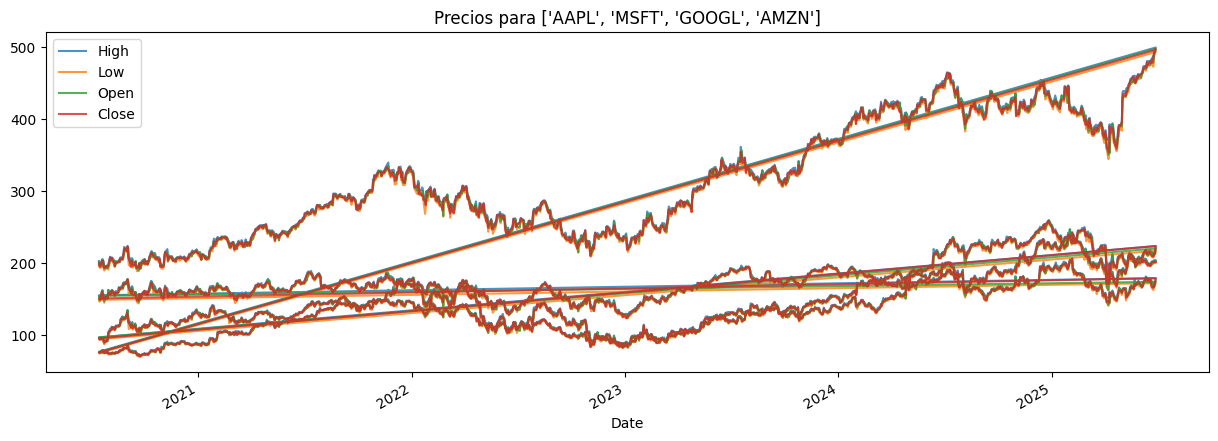

In [ ]:
# Ejemplo para ver solo:
top_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
df_filtered = df[df['Ticker'].isin(top_tickers)]

df_filtered[['High','Low','Open','Close']].plot(figsize=(15, 5), alpha=0.8)
plt.title(f"Precios para {top_tickers}")
plt.show()

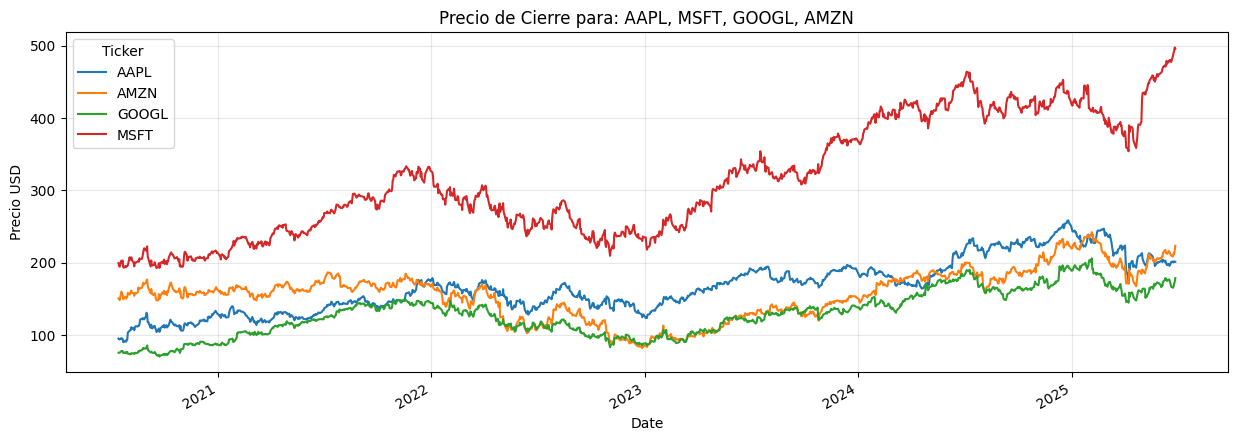

In [17]:
# 1. Definir la lista de tickers
top_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']

# 2. Filtrar
df_filtered = df[df['Ticker'].isin(top_tickers)]

# 3. Graficar detectando si 'Date' es índice o columna
try:
    # Si 'Date' es una columna normal
    df_pivot = df_filtered.pivot(index='Date', columns='Ticker', values='Close')
except KeyError:
    # Si 'Date' ya es el índice, pivotamos sin especificar index
    df_pivot = df_filtered.pivot(columns='Ticker', values='Close')

df_pivot.plot(figsize=(15, 5))
plt.title(f"Precio de Cierre para: {', '.join(top_tickers)}")
plt.ylabel("Precio USD")
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
ts = df['High']

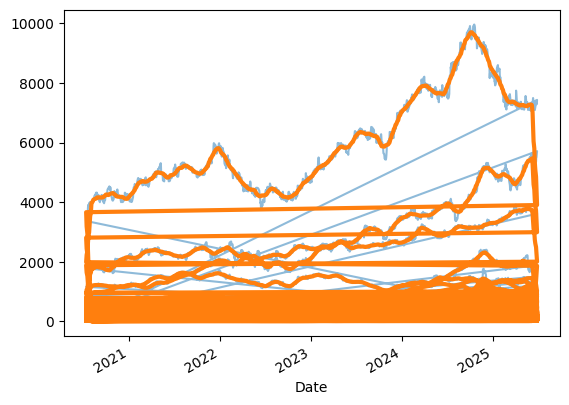

In [19]:
trend = ts.rolling(
    window=30,
    center=True,
    min_periods=15
).mean()

ax = ts.plot(alpha=0.5)
ax = trend.plot(ax=ax, linewidth=3)

<Axes: >

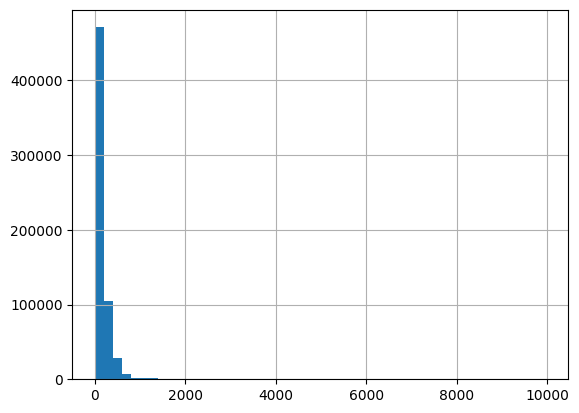

In [20]:
df.High.hist(bins=50)

No podemos asumir una distribución uniforme ni normal en el gráfico anterior, por eso el resumen estadístico nos puede ayudar más, para esto dividiremos los datos en 10 partes y calcularemos la media y la varianza de cada uno.

In [23]:
from statistics import stdev
mean=[]
std=[]
    
for i in range(0,10):
    mean.append(df['High'].iloc[(i*182):(i*182)+182].mean())
    std.append(stdev(df['High'].iloc[(i*182):(i*182)+182]))

In [24]:
pd.concat([pd.DataFrame(mean,columns=['mean']),pd.DataFrame(std,columns=['std'])], axis=1)

,mean,std
0,455.423151,66.417335
1,512.104731,94.837050
2,412.000624,25.412155
3,488.410444,47.539808
4,632.827960,23.581665
5,629.298913,32.680302
6,307.378076,167.455561
7,311.693572,38.972096
8,272.771868,49.134295
9,245.853297,28.760107


Arriba vemos cómo ambas medidas son claramente diferentes en cada fragmento. Sin embargo, al observar el gráfico, podríamos asumir una varianza constante como ondulación en la curva, pero sin duda la tendencia es la característica más destacada. Hasta ahora se puede asumir que se trata de una serie no estacionaria, pero para comprenderla mejor evaluaremos otros dos métodos.
La descomposición estacional es una función de la biblioteca statsmodels que permite descomponer la serie en tendencia, estacional y residual, ya sea aditiva o multiplicativa.

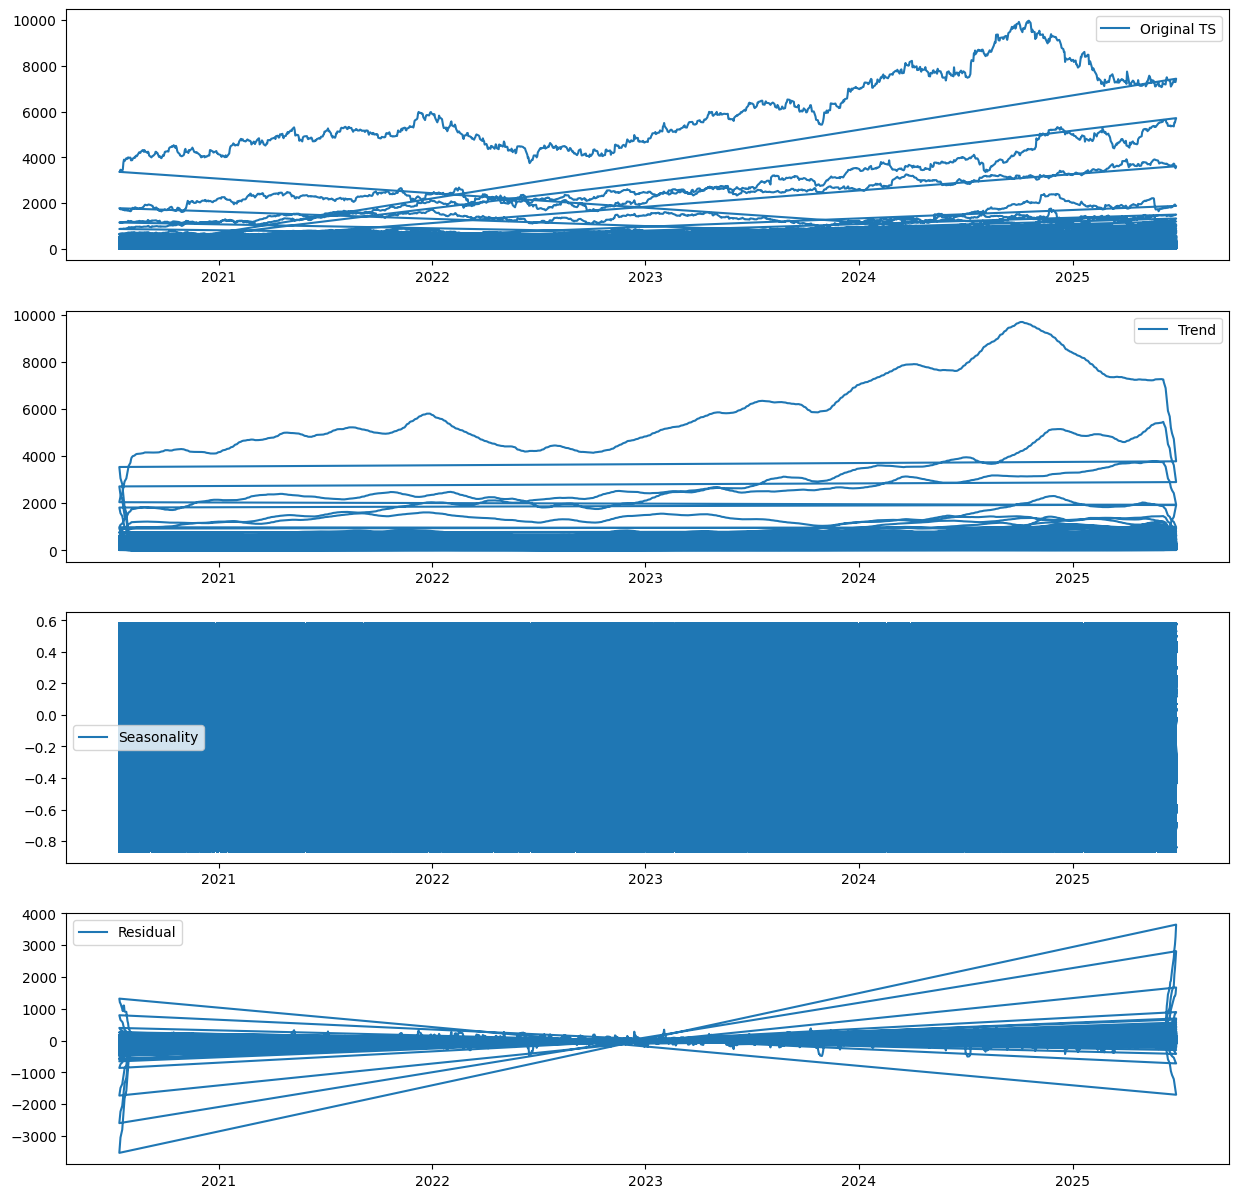

In [25]:
decompose_add=seasonal_decompose(df['High'], model='additive', period=30)
plt.figure(figsize=(15,15))
plt.subplot(411)
plt.plot(df['High'], label='Original TS')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(decompose_add.trend, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(decompose_add.seasonal,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(decompose_add.resid, label='Residual')
plt.legend(loc='best')

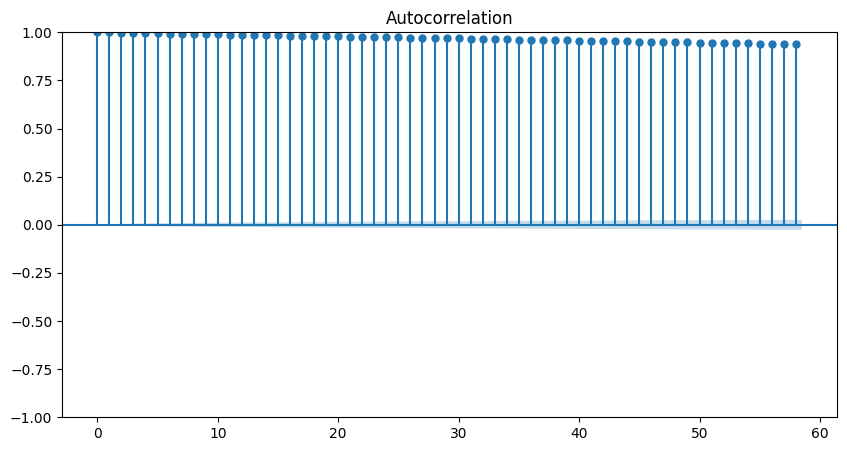

In [26]:
plt.rc("figure", figsize=(10,5))
plot_acf(df['High'])
print()

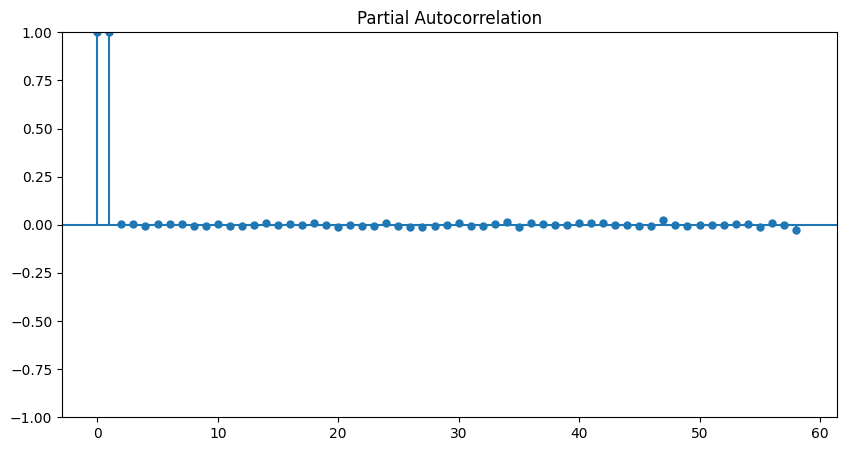

In [27]:
plt.rc("figure", figsize=(10,5))
plot_pacf(df['High'])
print()

## Split Data

In [28]:
split_idx = int(0.8 * len(ts))
ts_train = ts[:split_idx]
ts_test= ts[split_idx:]

## Scale Data

In [29]:
scaler = MinMaxScaler()
ts_train = scaler.fit_transform(ts_train.values.reshape(-1, 1))
ts_test = scaler.transform(ts_test.values.reshape(-1, 1))

## Create Sequence

In [48]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

In [49]:
seq_length = 5
X_train, y_train = create_sequences(ts_train, seq_length)
X_test, y_test = create_sequences(ts_test, seq_length)

In [50]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1455, 5, 1) (1455, 1)
(360, 5, 1) (360, 1)


# Forecasting

In [52]:
model = Sequential([
    Input(shape=(seq_length, 1)),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

In [53]:
callback = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[callback],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 0.1508 - val_loss: 0.0374
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0122 - val_loss: 0.0042
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0039 - val_loss: 6.9006e-04
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0021 - val_loss: 4.2743e-04
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020 - val_loss: 4.7718e-04
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0020 - val_loss: 5.5584e-04
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020 - val_loss: 4.8258e-04
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0019 - val_loss: 4.2067e-04
Epoch 9/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0017 - val_loss: 5.5724e-04
Epoch 10/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0017 - val_loss: 4.4557e-04
Epoch 11/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0016 - val_loss: 4.6068e-04
Epoch 12/200
21/

In [54]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


# Evaluate

In [55]:
def evaluate(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    return mse, rmse, mae

In [56]:
train_mse, train_rmse, train_mae = evaluate(y_train_orig, train_pred)
test_mse, test_rmse, test_mae = evaluate(y_test_orig, test_pred)

print(f"Test RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}")

Test RMSE: 24.7463, MAE: 17.2137, MSE: 612.3810
Test RMSE: 67.6727, MAE: 46.3550, MSE: 4579.5971


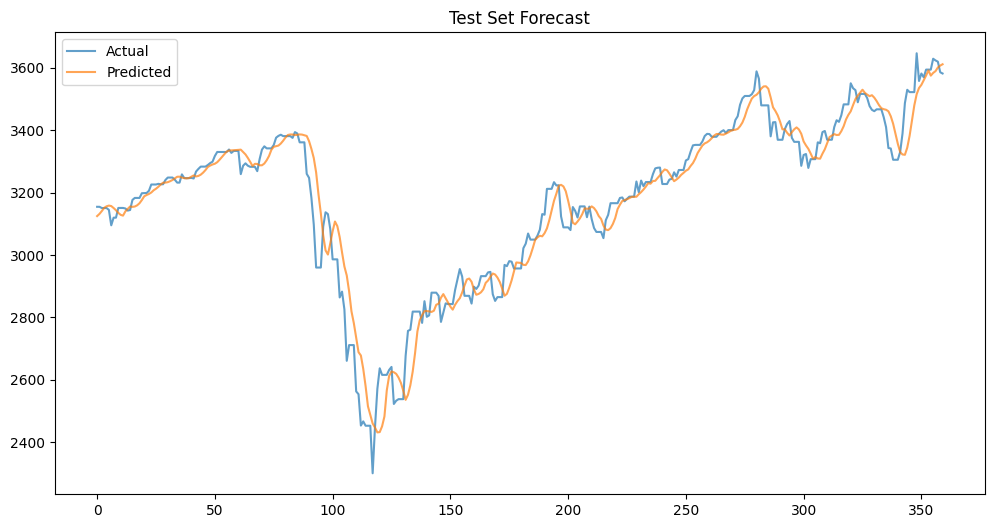

In [57]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', alpha=0.7)
plt.plot(test_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title("Test Set Forecast")
plt.show()

# Model Variant

In [58]:
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(seq_length, 1)),
    LSTM(100, return_sequences=True,),
    Dropout(0.2),
    LSTM(100,),
    Dropout(0.2),
    Dense(100),
    Dropout(0.2),
    Dense(25),
    Dense(1),
])
opt1=Adam(learning_rate=0.001,beta_1=0.9,beta_2=0.999)
model.compile(optimizer=opt1, loss='mse')

In [59]:
callback = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[callback],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - loss: 0.1020 - val_loss: 0.0340
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0101 - val_loss: 9.4706e-04
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0044 - val_loss: 4.0572e-04
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0035 - val_loss: 0.0022
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0031 - val_loss: 4.0252e-04
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0028 - val_loss: 8.8228e-04
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0029 - val_loss: 5.6902e-04
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0026 - val_loss: 3.9053e-04
Epoch 9/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0026 - val_loss: 6.1003e-04
Epoch 10/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0023 - val_loss: 5.4301e-04
Epoch 11/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0020 - val_loss: 0.0011
Epoch 12/200
21/21 ━

In [60]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [61]:
train_mse, train_rmse, train_mae = evaluate(y_train_orig, train_pred)
test_mse, test_rmse, test_mae = evaluate(y_test_orig, test_pred)

print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}")

Train RMSE: 25.6638, MAE: 18.8447, MSE: 658.6304
Test RMSE: 65.1895, MAE: 46.2328, MSE: 4249.6658


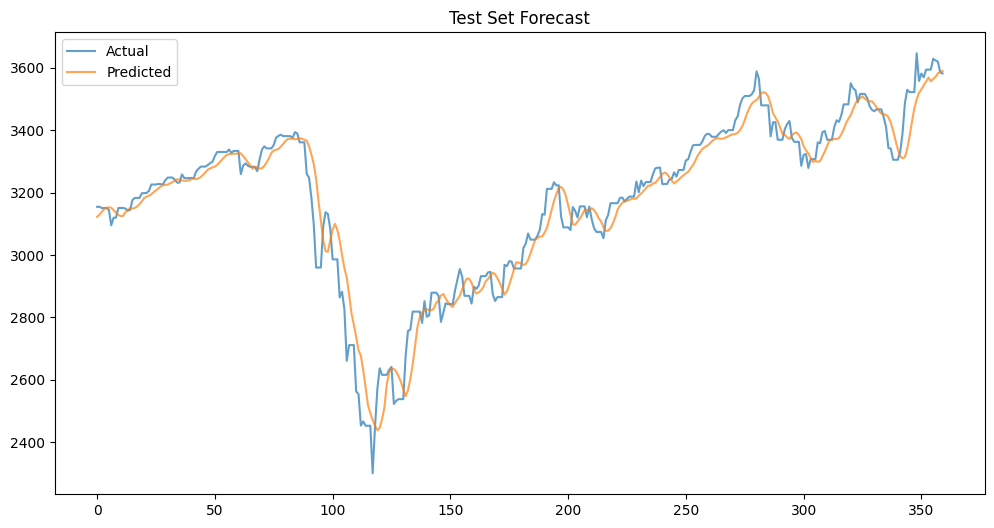

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', alpha=0.7)
plt.plot(test_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title("Test Set Forecast")
plt.show()

## Bidirectional LSTM

In [63]:
from tensorflow.keras.layers import Bidirectional
model = Sequential([
    Input(shape=(seq_length, 1)),
    Bidirectional(LSTM(200, return_sequences=True,)),
    Dropout(0.2),
    Bidirectional(LSTM(100,)),
    Dropout(0.2),
    Dense(100),
    Dropout(0.2),
    Dense(25),
    Dense(1),
])
model.compile(optimizer='adam', loss='mse')

In [64]:
callback = EarlyStopping(patience=10, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[callback],
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 13s 89ms/step - loss: 0.0703 - val_loss: 6.8460e-04
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0063 - val_loss: 0.0092
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0037 - val_loss: 8.4028e-04
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0028 - val_loss: 4.2885e-04
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0021 - val_loss: 5.9912e-04
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0020 - val_loss: 3.4620e-04
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0021 - val_loss: 3.8920e-04
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0021 - val_loss: 3.9217e-04
Epoch 9/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0017 - val_loss: 4.5319e-04
Epoch 10/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 11/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0019 - val_loss: 0.0011
Epoch 12/200
21/21 

In [65]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_orig = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [66]:
train_mse, train_rmse, train_mae = evaluate(y_train_orig, train_pred)
test_mse, test_rmse, test_mae = evaluate(y_test_orig, test_pred)

print(f"Train RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, MSE: {train_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}")

Train RMSE: 22.1101, MAE: 15.4191, MSE: 488.8585
Test RMSE: 59.6567, MAE: 42.1009, MSE: 3558.9245


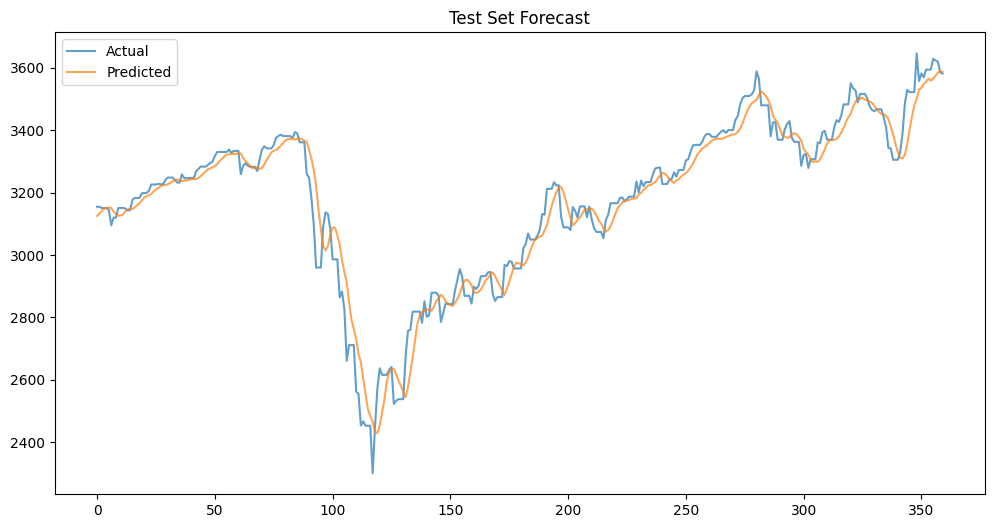

In [67]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', alpha=0.7)
plt.plot(test_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title("Test Set Forecast")
plt.show()

In [68]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test_orig, test_pred)
print("R²:", r2)

R²: 0.9490258824789443


## Peephole LSTM

In [69]:
class PeepholeLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, return_sequences=False):
        super().__init__()
        self.hidden_size = hidden_size
        self.return_sequences = return_sequences
        
        # Gate weights (input, forget, cell, output)
        self.weight_ih = nn.Parameter(torch.Tensor(4 * hidden_size, input_size))
        self.weight_hh = nn.Parameter(torch.Tensor(4 * hidden_size, hidden_size))
        
        # Peephole connections weights (input, forget, output)
        self.weight_pi = nn.Parameter(torch.Tensor(hidden_size))
        self.weight_pf = nn.Parameter(torch.Tensor(hidden_size))
        self.weight_po = nn.Parameter(torch.Tensor(hidden_size))
        
        # Biases
        self.bias = nn.Parameter(torch.Tensor(4 * hidden_size))
        
        self.init_parameters()

    def init_parameters(self):
        stdv = 1.0 / (self.hidden_size ** 0.5)
        for weight in self.parameters():
            nn.init.uniform_(weight, -stdv, stdv)

    def forward(self, x):
        # x shape: (batch_size, seq_length, input_size)
        batch_size, seq_length, _ = x.size()
        
        # Initialize hidden state and cell state
        h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
        
        outputs = []
        
        for t in range(seq_length):
            x_t = x[:, t, :]
            
            # Linear transformations
            gates = (x_t @ self.weight_ih.t() + self.bias +
                     h_t @ self.weight_hh.t())
            
            # Split gates
            i_t, f_t, g_t, o_t = gates.chunk(4, 1)
            
            # Apply peephole connections
            i_t = i_t + c_t * self.weight_pi
            f_t = f_t + c_t * self.weight_pf
            
            # Activation functions
            i_t = torch.sigmoid(i_t)
            f_t = torch.sigmoid(f_t)
            g_t = torch.tanh(g_t)
            
            # Update cell state
            c_t = f_t * c_t + i_t * g_t
            
            # Output gate with peephole
            o_t = o_t + c_t * self.weight_po
            o_t = torch.sigmoid(o_t)
            
            # Update hidden state
            h_t = o_t * torch.tanh(c_t)
            
            if self.return_sequences:
                outputs.append(h_t)
        
        if self.return_sequences:
            # Stack all hidden states
            return torch.stack(outputs, dim=1)
        else:
            # Return only the last hidden state
            return h_t

class LSTMModel(nn.Module):
    def __init__(self, seq_length, input_size=1):
        super().__init__()
        self.lstm1 = PeepholeLSTM(input_size, 100, return_sequences=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = PeepholeLSTM(100, 100, return_sequences=False)
        self.dropout2 = nn.Dropout(0.2)
        self.dense1 = nn.Linear(100, 100)
        self.dropout3 = nn.Dropout(0.2)
        self.dense2 = nn.Linear(100, 25)
        self.output = nn.Linear(25, 1)
        
    def forward(self, x):
        # Input shape: (batch_size, seq_length, input_size)
        x = self.lstm1(x)
        x = self.dropout1(x)
        x = self.lstm2(x)
        x = self.dropout2(x)
        x = torch.relu(self.dense1(x))
        x = self.dropout3(x)
        x = torch.relu(self.dense2(x))
        return self.output(x)

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# 1. Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# 2. Create validation split (15% of training data)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_tensor, y_train_tensor, test_size=0.15, random_state=42
)

# 3. Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_split, y_train_split)
val_dataset = TensorDataset(X_val_split, y_val_split)
test_dataset = TensorDataset(X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# 5. Initialize model, loss, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel(seq_length=X_train.shape[1]).to(device)
criterion = nn.MSELoss()  # Use appropriate loss for your task
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 6. Training with early stopping
epochs = 200
patience = 15
best_val_loss = float('inf')
counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    
    # Calculate epoch losses
    train_loss = train_loss / len(train_loader.dataset)
    val_loss = val_loss / len(val_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')  # Save best model
    else:
        counter += 1
        if counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

# 7. Load best model for predictions
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# 8. Make predictions on test data
test_predictions = []
with torch.no_grad():
    for inputs in test_loader:
        inputs = inputs[0].to(device)
        outputs = model(inputs)
        test_predictions.append(outputs.cpu().numpy())

test_predictions = np.vstack(test_predictions)

# 9. Convert to 1D array if needed
if test_predictions.shape[1] == 1:
    test_predictions = test_predictions.flatten()

print("Test predictions shape:", test_predictions.shape)

/tmp/ipykernel_36/187741729.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
/tmp/ipykernel_36/187741729.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
/tmp/ipykernel_36/187741729.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


Epoch 1/200 | Train Loss: 0.182757 | Val Loss: 0.079210
Epoch 2/200 | Train Loss: 0.053720 | Val Loss: 0.037103
Epoch 3/200 | Train Loss: 0.024231 | Val Loss: 0.008538
Epoch 4/200 | Train Loss: 0.007755 | Val Loss: 0.003462
Epoch 5/200 | Train Loss: 0.006111 | Val Loss: 0.002224
Epoch 6/200 | Train Loss: 0.005060 | Val Loss: 0.001666
Epoch 7/200 | Train Loss: 0.005422 | Val Loss: 0.001239
Epoch 8/200 | Train Loss: 0.003486 | Val Loss: 0.000767
Epoch 9/200 | Train Loss: 0.003240 | Val Loss: 0.000600
Epoch 10/200 | Train Loss: 0.003299 | Val Loss: 0.000487
Epoch 11/200 | Train Loss: 0.002993 | Val Loss: 0.000423
Epoch 12/200 | Train Loss: 0.002864 | Val Loss: 0.000369
Epoch 13/200 | Train Loss: 0.002355 | Val Loss: 0.000469
Epoch 14/200 | Train Loss: 0.002361 | Val Loss: 0.000442
Epoch 15/200 | Train Loss: 0.002299 | Val Loss: 0.000382
Epoch 16/200 | Train Loss: 0.002671 | Val Loss: 0.000482
Epoch 17/200 | Train Loss: 0.002570 | Val Loss: 0.001115
Epoch 18/200 | Train Loss: 0.002730 | Va

In [79]:
test_pred = test_predictions.reshape(-1, 1)
test_pred = scaler.inverse_transform(test_pred)

In [84]:
test_mse, test_rmse, test_mae = evaluate(y_test_orig, test_pred)

print(f"Test RMSE: {test_rmse:.4f}, MAE: {test_mae:.4f}, MSE: {test_mse:.4f}")

Test RMSE: 87.1312, MAE: 72.5558, MSE: 7591.8499


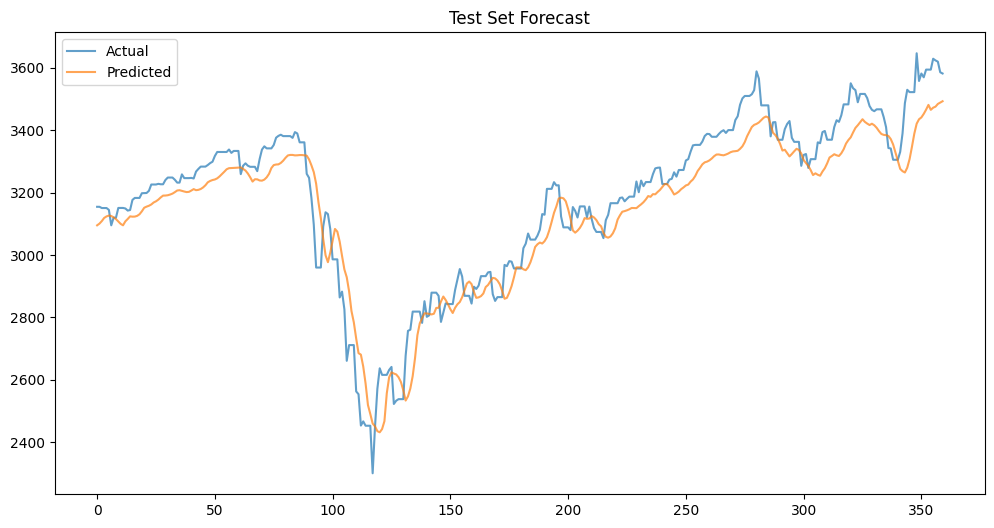

In [85]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_orig, label='Actual', alpha=0.7)
plt.plot(test_pred, label='Predicted', alpha=0.7)
plt.legend()
plt.title("Test Set Forecast")
plt.show()

# Anomaly Detection

## Point anomaly

In [69]:
def error_vectors(y_true, y_pred):
    return y_true - y_pred       

E_train = error_vectors(y_train_orig, train_pred)
E_test  = error_vectors(y_test_orig, test_pred)

In [70]:
# Fit a multivariate Gaussian on vN2 errors
from scipy.stats import multivariate_normal

mu    = E_train.mean(axis=0)
Sigma = np.cov(E_train.T, bias=True)
gauss = multivariate_normal(mean=mu, cov=Sigma, allow_singular=True)

p_train   = gauss.pdf(E_train)
p_test = gauss.pdf(E_test)

# (Optional) restrict to a slice you believe is 100% normal
CLEAN_START, CLEAN_STOP = None, None 
if CLEAN_START:
    clean_mask = (df.index[shift:][idx_v2_w] >= CLEAN_START) & \
                 (df.index[shift:][idx_v2_w] <= CLEAN_STOP)
    tau_fixed = np.percentile(p_v2[clean_mask], 0.5)
else:
    tau_fixed = np.percentile(p_train, 0.005)              # default 0.5٪
print(f"Fixed τ (0.5 % quantile) = {tau_fixed:.3e}")


Fixed τ (0.5 % quantile) = 1.896e-08


Alarms in test slice: 27  (7.50% of time)


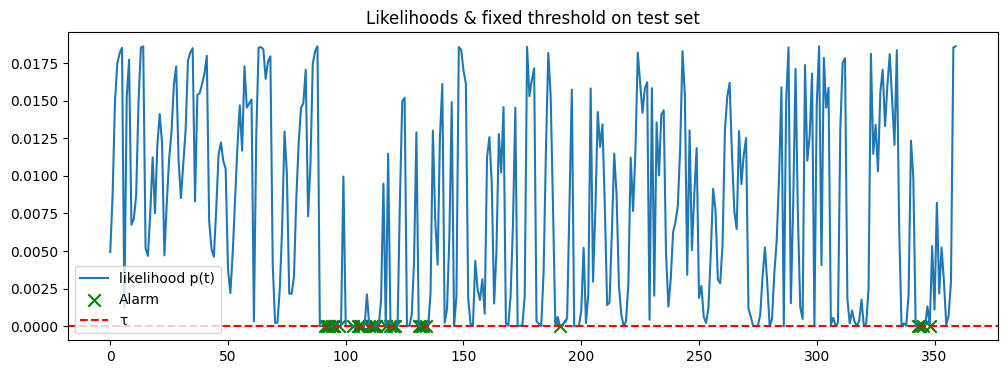

In [72]:
alarms_test = (p_test < tau_fixed)
print(f"Alarms in test slice: {alarms_test.sum()}  "
      f"({alarms_test.mean()*100:.2f}% of time)")

plt.figure(figsize=(12,4))
plt.plot(p_test, label='likelihood p(t)')

# Green crosses at alarm points
plt.scatter(
    np.where(alarms_test)[0],      # x positions (indices)
    p_test[alarms_test],           # y positions (likelihoods)
    color='g', marker='x', s=80,   # 'x' marker, green color, size 80
    label='Alarm'
)

plt.axhline(tau_fixed, color='r', linestyle='--', label='τ')
plt.legend()
plt.title('Likelihoods & fixed threshold on test set')
plt.show()

## Collective Anomaly

Collective alarms detected: 0 (0.00% of time)


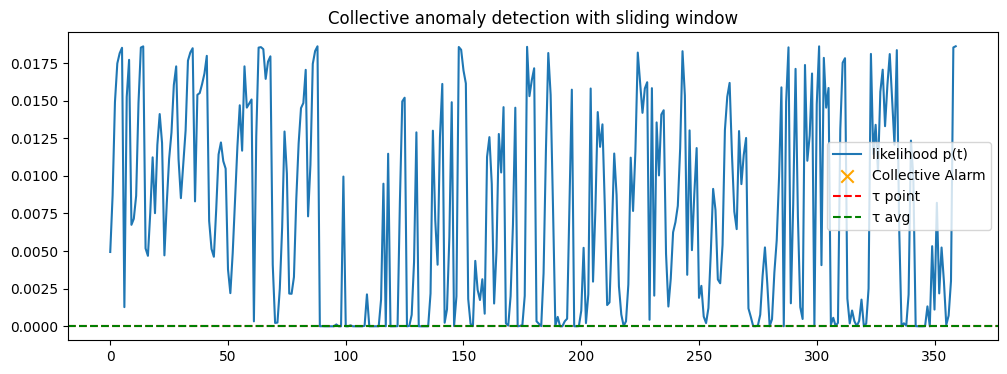

In [74]:
window_size = 30
min_points_below = 16   
tau_point = tau_fixed  
tau_avg = tau_fixed

collective_alarms = np.zeros(len(p_test), dtype=bool)

for start in range(len(p_test) - window_size + 1):
    window_vals = p_test[start:start+window_size]

    
    cond1 = window_vals.mean() < tau_avg

    
    cond2 = np.sum(window_vals < tau_point) >= min_points_below

    if cond1 and cond2:
        collective_alarms[start:start+window_size] = True

print(f"Collective alarms detected: {collective_alarms.sum()} "
      f"({collective_alarms.mean()*100:.2f}% of time)")


plt.figure(figsize=(12,4))
plt.plot(p_test, label='likelihood p(t)')


plt.scatter(
    np.where(collective_alarms)[0],
    p_test[collective_alarms],
    color='orange', marker='x', s=80,
    label='Collective Alarm'
)

plt.axhline(tau_point, color='r', linestyle='--', label='τ point')
plt.axhline(tau_avg, color='g', linestyle='--', label='τ avg')
plt.legend()
plt.title('Collective anomaly detection with sliding window')
plt.show()